# Домашнє завдання 12. Transfer learning для класифікації рентген-знімків
Дата заняття: 26.06.2026 (пт)
Модуль: Модуль 5. Нейронні мережі в комп'ютерному зорі

### Мета
Навчити модель для класифікації рентген-знімків через transfer learning.

## Завдання
Доробити notebook-заготовку homework_12_pneumonia_resnet18.ipynb.

## Завдання. ResNet18 для класифікації пневмонії
Компанія MediScan AI впроваджує модель, яка за рентген-знімками грудної клітки визначає наявність пневмонії. Побудуйте навчальний прототип такої моделі на датасеті Chest X-Ray Pneumonia, використовуючи transfer learning і методи регуляризації.

1. Підготуйте датасет Chest X-Ray Pneumonia:
    + завантажте зображення;
    + виконайте resize до 224 x 224;
    + виконайте нормалізацію;
    + розділіть дані на train/test;
    + створіть DataLoader для train і test.
2. Використайте переднавчену модель ResNet18:
    + заморозьте згорткові шари;
    + замініть класифікатор на новий шар Linear(512, 2);
    + використайте CrossEntropyLoss як функцію втрат;
    + використайте оптимізатор Adam з lr=0.0001;
    + навчіть модель протягом 5 епох.
3. Оцініть якість моделі на test set:
    + порахуйте Accuracy, Precision, Recall і F1-score;
    + побудуйте confusion matrix;
    + збережіть навчену модель у файл pneumonia_resnet18.pth.
4. Покажіть результати роботи моделі:
    + відобразіть 8 випадкових зображень із тестової вибірки;
    + підпишіть передбачений і реальний клас;
    + збережіть графік під іменем pneumonia_predictions.png.
5. Напишіть короткий висновок: наскільки модель готова до впровадження і які обмеження вона має як навчальний прототип.

#### Що здати
Файл homework_12_pneumonia_resnet18.ipynb.

# Pneumonia classification with ResNet18

Компанія **MediScan AI** впроваджує модель, яка за рентген-знімками грудної клітки визначає наявність пневмонії.

Потрібно підготувати датасет **Chest X-Ray Pneumonia**, навчити `ResNet18` через transfer learning, оцінити метрики й зберегти результати.

## Що потрібно отримати в кінці

1. Навчену модель `pneumonia_resnet18.pth`.
2. Графік з 8 тестовими прикладами `pneumonia_predictions.png`.
3. Метрики `Accuracy`, `Precision`, `Recall`, `F1-score` і confusion matrix.
4. Короткий висновок про готовність моделі до впровадження.


## 0. Імпорти та налаштування

Запустіть цю клітинку першою. За потреби встановіть бібліотеки з першого закоментованого рядка.


In [1]:
# Якщо потрібно, встановіть бібліотеки:
# pip install torch torchvision scikit-learn matplotlib pandas kagglehub

from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

RANDOM_STATE = 42
IMG_SIZE = 224
BATCH_SIZE = 32
N_EPOCHS = 5
LEARNING_RATE = 0.0001

MODEL_PATH = "pneumonia_resnet18.pth"
PREDICTIONS_PLOT_PATH = "pneumonia_predictions.png"

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)


PyTorch version: 2.12.1+cpu
Device: cpu


## 1. Підготовка датасету

Потрібен датасет **Chest X-Ray Pneumonia** у структурі папок, сумісній з `ImageFolder`:

```text
data/chest_xray/
  train/
    NORMAL/
    PNEUMONIA/
  test/
    NORMAL/
    PNEUMONIA/
```

Можна завантажити датасет вручну або через Kaggle/KaggleHub. Після завантаження перевірте, що `DATA_ROOT` вказує саме на папку `chest_xray`.


In [2]:
DATA_ROOT = Path("data/chest_xray")

# Варіант для KaggleHub. Розкоментуйте, якщо хочете завантажити датасет автоматично.
# import kagglehub
# downloaded_path = Path(kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia"))
# DATA_ROOT = downloaded_path / "chest_xray"

print("DATA_ROOT:", DATA_ROOT.resolve())

expected_dirs = [
    DATA_ROOT / "train" / "NORMAL",
    DATA_ROOT / "train" / "PNEUMONIA",
    DATA_ROOT / "test" / "NORMAL",
    DATA_ROOT / "test" / "PNEUMONIA",
]

for folder in expected_dirs:
    status = "OK" if folder.exists() else "not found"
    print(f"{status:9} {folder}")


DATA_ROOT: C:\Users\Анютка\Desktop\лекції\Створення AI додатків з використанням Python\AI_Python\data\chest_xray
not found data\chest_xray\train\NORMAL
not found data\chest_xray\train\PNEUMONIA
not found data\chest_xray\test\NORMAL
not found data\chest_xray\test\PNEUMONIA


In [8]:
import kagglehub

downloaded_path = Path(kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia"))
DATA_ROOT = downloaded_path / "chest_xray"

print(f"DATA_ROOT: {DATA_ROOT}")


if DATA_ROOT.exists():
    print("Датасет завантажено!")
else:
    print("Помилка завантаження")

DATA_ROOT: C:\Users\Анютка\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2\chest_xray
Датасет завантажено!


In [11]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=7),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = None
test_dataset = None
train_loader = None
test_loader = None
class_names = None

if DATA_ROOT.exists():
    train_dataset = datasets.ImageFolder(DATA_ROOT / "train", transform=train_transform)
    test_dataset = datasets.ImageFolder(DATA_ROOT / "test", transform=test_transform)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    class_names = train_dataset.classes
    print("Classes:", class_names)
    print("class_to_idx:", train_dataset.class_to_idx)
    print("Train images:", len(train_dataset))
    print("Test images:", len(test_dataset))
else:
    print("TODO: завантажте датасет і виставте правильний DATA_ROOT.")

Classes: ['NORMAL', 'PNEUMONIA']
class_to_idx: {'NORMAL': 0, 'PNEUMONIA': 1}
Train images: 5216
Test images: 624


### 1.2. Баланс класів

Порахуйте, скільки зображень кожного класу є у train/test. Для медичних задач дисбаланс класів може сильно впливати на `Precision` і `Recall`.


In [ ]:
def dataset_class_counts(dataset):
    labels = [label for _, label in dataset.samples]
    counts = pd.Series(labels).value_counts().sort_index()
    return pd.DataFrame({
        "class": [dataset.classes[i] for i in counts.index],
        "count": counts.values,
        "share": (counts.values / counts.values.sum()).round(3),
    })


# TODO: перевірте кількість і частку класів у train_dataset.
# TODO: перевірте кількість і частку класів у test_dataset.
train_counts = dataset_class_counts(train_dataset)
print(train_counts)
print()
test_counts = dataset_class_counts(test_dataset)
print(test_counts)
print()
print (f"Train: {train_counts['count'].sum()} зображень")
print(f"Test:  {test_counts['count'].sum()} зображень")
print(f"Total: {train_counts['count'].sum() + test_counts['count'].sum()} зображень")

       class  count  share
0     NORMAL   1341  0.257
1  PNEUMONIA   3875  0.743

       class  count  share
0     NORMAL    234  0.375
1  PNEUMONIA    390  0.625

Train: 5216 зображень
Test:  624 зображень
Total: 5840 зображень


### 1.3. Перевірка batch

Перед навчанням переконайтеся, що `DataLoader` повертає тензори форми `(batch, 3, 224, 224)`.


Images shape: (32, 3, 224, 224)
Labels shape: (32,)
First labels: ['PNEUMONIA', 'PNEUMONIA', 'NORMAL', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA']


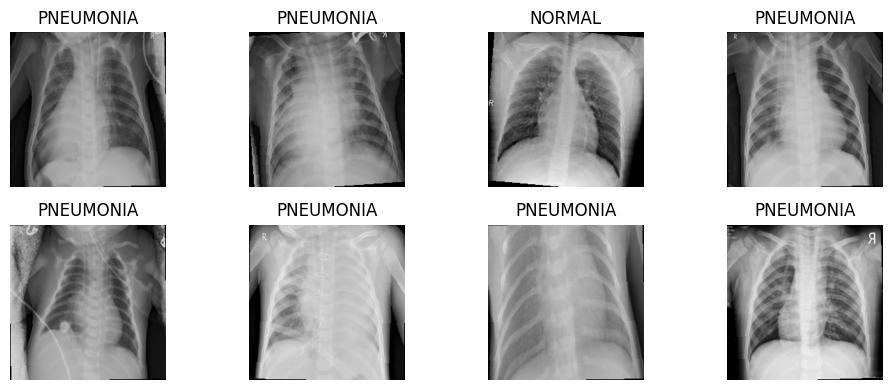

In [17]:
def denormalize_image(image_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    image = image_tensor.cpu() * std + mean
    return torch.clamp(image, 0, 1)

if train_loader is not None:
    images, labels = next(iter(train_loader))
    print("Images shape:", tuple(images.shape))
    print("Labels shape:", tuple(labels.shape))
    print("First labels:", [class_names[i] for i in labels[:8].tolist()])

    plt.figure(figsize=(10, 4))
    for i in range(min(8, len(images))):
        plt.subplot(2, 4, i + 1)
        image = denormalize_image(images[i]).permute(1, 2, 0).numpy()
        plt.imshow(image)
        plt.title(class_names[labels[i].item()])
        plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Спочатку створіть train_loader.")


## 2. ResNet18 для класифікації пневмонії

Використайте переднавчену `ResNet18`, заморозьте згорткову частину й замініть classification head на `Linear(512, 2)`.

In [19]:
# TODO: завантажте pretrained ResNet18.
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# TODO: заморозьте згорткові шари моделі.
for param in model.parameters():
    param.requires_grad = False

# TODO: замініть classification head на nn.Linear(512, 2).
model.fc = nn.Linear(model.fc.in_features, 2)

# TODO: перенесіть модель на device.
model = model.to(device)

# TODO: створіть CrossEntropyLoss.
loss_fn = nn.CrossEntropyLoss()

# TODO: створіть Adam optimizer з lr=0.0001.
# В optimizer передайте тільки параметри нового класифікатора.
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.0001)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Анютка/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


### 2.1. Train loop

Навчіть модель протягом `5` епох. У train loop потрібно виконати forward pass, loss, backward pass і optimizer step. Для test set використовуйте `torch.no_grad()`.


In [25]:
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    # TODO: реалізуйте одну епоху навчання.
    # Поверніть середній loss і accuracy за епоху.
    model.train()

    total_loss = 0.0
    total_items = 0
    total_correct = 0

    for images, labels in loader:
        
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad(set_to_none=True)
        
        logits = model(images)
        loss = loss_fn(logits, labels)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * len(labels)
        total_items += len(labels)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        
    return {
        "loss": total_loss / total_items,
        "accuracy": total_correct / total_items
    }

@torch.no_grad()
def evaluate_loss_accuracy(model, loader, loss_fn, device):
    # TODO: реалізуйте оцінювання без оновлення ваг.
    # Поверніть середній loss і accuracy.
    
    model.eval()
    
    total_loss = 0.0
    total_items = 0
    total_correct = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        logits = model(images)
        loss = loss_fn(logits, labels)
        
        total_loss += loss.item() * labels.size(0)
        total_items += labels.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        
    return {
        "loss": total_loss / total_items,
        "accuracy": total_correct / total_items
    }

In [26]:
history = []

# TODO: запустіть навчання на N_EPOCHS епох.
# Для кожної епохи збережіть train_loss, train_acc, test_loss, test_acc у history.
# Після навчання створіть history_df = pd.DataFrame(history).

for epoch in range(1, N_EPOCHS + 1):
    train_metrics = train_one_epoch(model, train_loader, loss_fn, optimizer, device)

    test_metrics = evaluate_loss_accuracy(model, test_loader, loss_fn, device)

    history.append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_acc": train_metrics["accuracy"],
        "test_loss": test_metrics["loss"],
        "test_acc": test_metrics["accuracy"],

    })

    print(f"epoch: {epoch} | train_loss: {train_metrics["loss"]} | train_acc: {train_metrics["accuracy"]}"
          f"| test_loss: {test_metrics["loss"]} | test_acc: {test_metrics["accuracy"]}")


history_df = pd.DataFrame(history)


epoch: 1 | train_loss: 0.4839755033422833 | train_acc: 0.7632285276073619| test_loss: 0.49658815257060224 | test_acc: 0.7339743589743589
epoch: 2 | train_loss: 0.33275678013365695 | train_acc: 0.8636886503067485| test_loss: 0.3744095338460727 | test_acc: 0.8557692307692307
epoch: 3 | train_loss: 0.27890319308620287 | train_acc: 0.8943634969325154| test_loss: 0.34629225730895996 | test_acc: 0.8653846153846154
epoch: 4 | train_loss: 0.24446741445847084 | train_acc: 0.910467791411043| test_loss: 0.3177106514191016 | test_acc: 0.8766025641025641
epoch: 5 | train_loss: 0.22619455609402042 | train_acc: 0.9171779141104295| test_loss: 0.3091015685827304 | test_acc: 0.8766025641025641


### 2.2. Графік навчання

Будуємо графіки `Loss` і `Accuracy` для train/test. Подивіться, чи не зростає test loss і чи не є різниця між train/test accuracy надто великою.


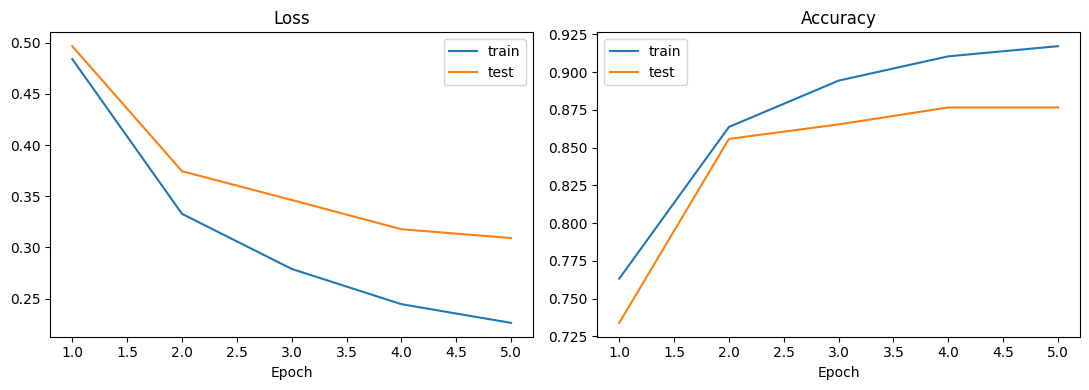

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
axes[0].plot(history_df["epoch"], history_df["test_loss"], label="test")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_acc"], label="train")
axes[1].plot(history_df["epoch"], history_df["test_acc"], label="test")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

Графі loss - показники майже рівномірно знжуються без ознак перенавчання.

Графік accurancy - майже рівномірно зростає, різниця на 5й епосі приблизно 4%, більша у train (0.9171779141104295), при test(0.8766025641025641) 

Модель може досить непогано вирішувати поставлену задачу 

## 3. Оцінка якості

Рахуємо `Accuracy`, `Precision`, `Recall` і `F1-score`. Для медичної задачі окремо зверніть увагу на `Recall` для класу `PNEUMONIA`: пропущені випадки пневмонії можуть бути критичними.

In [28]:
def collect_predictions(model, loader, device):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            logits = model(images)
            predictions = logits.argmax(dim=1).cpu().numpy()

            y_true.extend(labels.numpy().tolist())
            y_pred.extend(predictions.tolist())

    return np.array(y_true), np.array(y_pred)


y_true, y_pred = collect_predictions(model, test_loader, device)

positive_label = next(
    (idx for name, idx in train_dataset.class_to_idx.items() if name.lower() == "pneumonia"),
    1,
)

metrics = {
    "accuracy": accuracy_score(y_true, y_pred),
    "precision": precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
    "recall": recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
    "f1_score": f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
}

pd.DataFrame([metrics]).round(4)

,accuracy,precision,recall,f1_score
0,0.8766,0.8565,0.9641,0.9071


Всі показники досить високі, що говорить про точність та збалансованість моделі. 

              precision    recall  f1-score   support

      NORMAL       0.92      0.73      0.82       234
   PNEUMONIA       0.86      0.96      0.91       390

    accuracy                           0.88       624
   macro avg       0.89      0.85      0.86       624
weighted avg       0.88      0.88      0.87       624



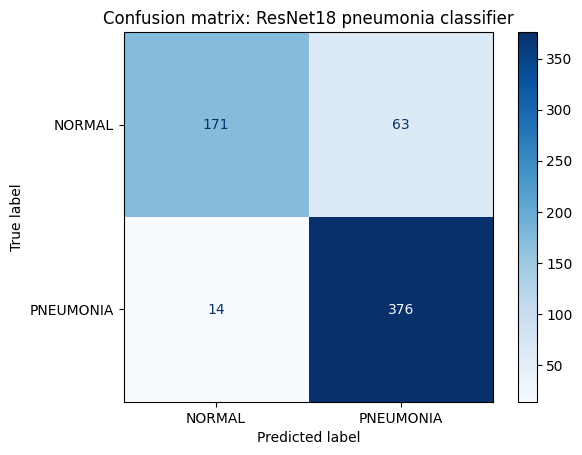

In [29]:
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

display_cm.plot(cmap="Blues", values_format="d")
plt.title("Confusion matrix: ResNet18 pneumonia classifier")
plt.show()

Всього 624 рентгенограм

63 зразки - модель назвала, що це пневмонія, але вони виявилися нормою

14 зразків - модель допустила помилку, назвавши пневмонію нормою - це погано 

але загалом рультат розпізнавання високий де 376 рентгенограм  (96%) були з пневмонією, і 171 - норма.

На мою думку, це маленький відсоток помилок (4%) в медичні практиці для моделі, який можна перевірити вручну.

### 3.1. Збереження моделі

Зберігаємо навчену модель у файл `pneumonia_resnet18.pth`. Не лише ваги, а й `class_to_idx`, щоб пізніше правильно інтерпретувати класи.

In [30]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_to_idx": train_dataset.class_to_idx,
        "image_size": IMG_SIZE,
        "model_name": "resnet18",
    },
    MODEL_PATH,
)

print(f"Model saved to: {MODEL_PATH}")


Model saved to: pneumonia_resnet18.pth


## 4. Візуалізація результатів

Показуємо `8` випадкових зображень із test set. У заголовку кожного зображення має бути реальний і передбачений клас. Зберігаємо графік у файл `pneumonia_predictions.png`.


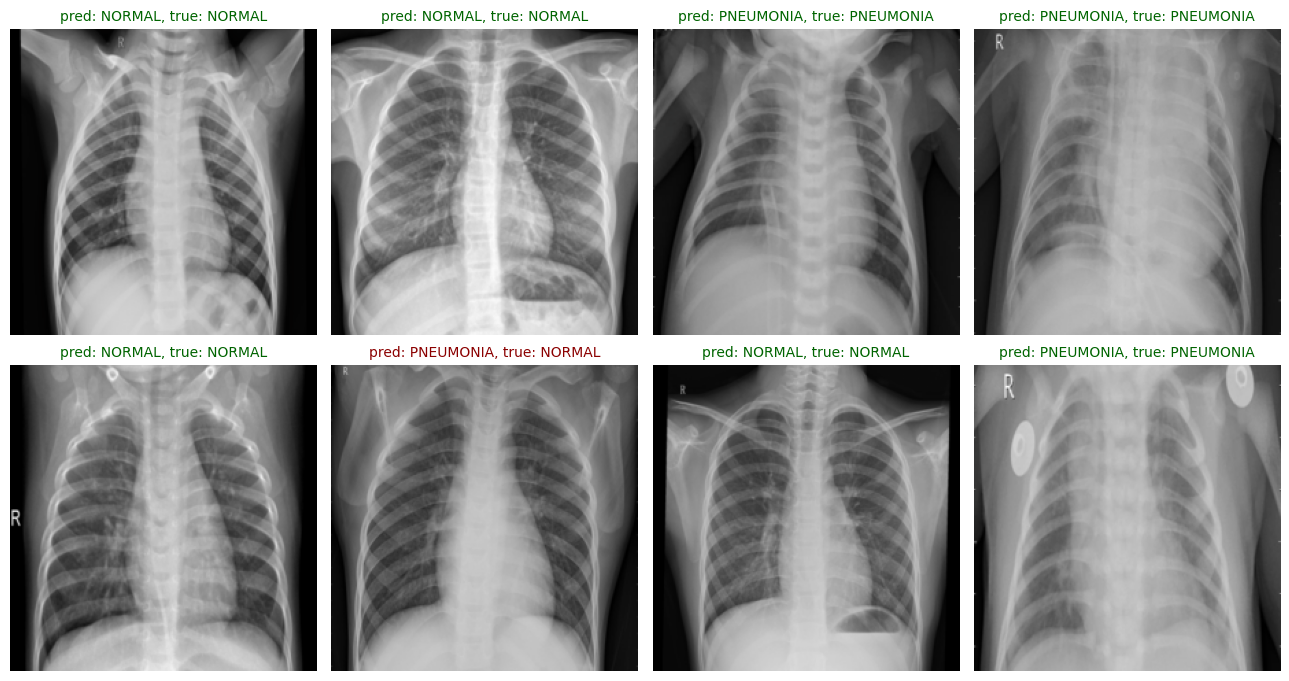

Predictions plot saved to: pneumonia_predictions.png


In [31]:
def show_random_predictions(model, dataset, class_names, device, n_images=8, save_path=PREDICTIONS_PLOT_PATH):
    model.eval()
    n_images = min(n_images, len(dataset))
    indices = random.sample(range(len(dataset)), k=n_images)

    fig, axes = plt.subplots(2, 4, figsize=(13, 7))
    axes = axes.ravel()

    with torch.no_grad():
        for ax, idx in zip(axes, indices):
            image_tensor, true_label = dataset[idx]
            logits = model(image_tensor.unsqueeze(0).to(device))
            pred_label = logits.argmax(dim=1).item()

            image = denormalize_image(image_tensor).permute(1, 2, 0).numpy()
            ax.imshow(image)
            ax.axis("off")

            color = "darkgreen" if pred_label == true_label else "darkred"
            ax.set_title(
                f"""pred: {class_names[pred_label]}, true: {class_names[true_label]}""",
                color=color,
                fontsize=10,
            )

    for ax in axes[n_images:]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Predictions plot saved to: {save_path}")


show_random_predictions(model, test_dataset, class_names, device)

## 5. Висновок

Напишіть короткий висновок українською мовою.

Орієнтири для висновку:

- Які значення `Accuracy`, `Precision`, `Recall`, `F1-score` отримала модель?
- Чи достатній `Recall` для класу `PNEUMONIA`?
- Які помилки видно у confusion matrix?
- Чому це навчальний прототип, а не готова медична система?


**Ваш висновок:**

> TODO: напишіть 4-6 речень про якість моделі, обмеження датасету й готовність до впровадження.

| Метрика | Значення |
|:--------|:--------:|
| **Accuracy** | 0.8766 (87.66%) |
| **Precision** | 0.8565 (85.65%) |
| **Recall** | 0.9641 (96.41%) |
| **F1-score** | 0.9071 (90.71%) |


Accuracy - загалом правильна в 87.66% випадків, тобто на  100 випадків - 88 вияви

модель правильно передбачила 96% випадків пневмоній (Recall), 
у 4% - 14 випадків -  виявлена попилка False Negative - це погано, але не критично.

Точність моделі (Precision), тобто виявила пневмонію - 85% 


у 63 випадках False Positive  - модель назва пневмонію, але була норма, такі випадки варто теж перевіряти вручну. 

Можель точна і збалансована.

Дана модель може бути допоміжним інструментом в прктиці лікаря, але функціонувати повноцінним інструментом не може. В комплексній роботі, модель зменшить навантаження на лікаря, звертаючи увагу на діляки рентгенограми (можливо підсвічуючи різними кольорами), які варті більшої уваги.

Заключний діагноз має залишатися за лікарем.